In [10]:
class AppState(dict):
    name: str

def hitl_router(p_state: AppState) -> str:
    """Route based on human review: proceed to architect or back to planner."""
    if p_state["status"] == "PLAN_REJECTED":
        return "REJECTED"
    else:
        return "APPROVED"

def coder_router(p_state: AppState) -> str:
    if p_state["status"]=="DONE":
        return "END"
    else:
        return "coder_node"

def reviewer_router(p_state: AppState) -> str:
    if p_state["status"]=="FIXING":
        return "END"
    else:
        return "coder_node"

In [11]:
from langgraph.graph import StateGraph, START, END

#Call memory here
builder = StateGraph(AppState)

def reviewer_router(p_state: AppState) -> str:
    if p_state["name"]=="DONE":
        return "END"
    else:
        return "coder_node"

def f1():
    print("hello")

# NODES
builder.add_node("input_node", f1)
builder.add_node("planner_node", f1)
builder.add_node("architect_node", f1)
builder.add_node("coder_node", f1)
builder.add_node("hitl_review_node", f1)


# TO BE DONE LATER WITH MORE TIME
# builder.add_node("reviewer_node", subagent_reviewer)
# builder.add_node("fixer_node", subagent_fixer)

# EDGES
builder.add_edge(START, "input_node")
builder.add_edge("input_node", "planner_node")
builder.add_edge("planner_node", "hitl_review_node")
builder.add_conditional_edges(
    "hitl_review_node",
    hitl_router, {
        "APPROVED": "architect_node",
        "REJECTED": "planner_node",
    }
)
builder.add_edge("architect_node", "coder_node")
builder.add_conditional_edges(
    "coder_node",
    coder_router,{
        "END": END,
        "coder_node": "coder_node",
    }
)


graph = builder.compile()

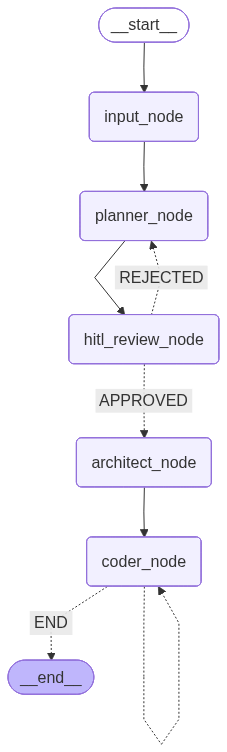

In [14]:
from IPython.display import Image, display

# Display the LangGraph graph as PNG
display(Image(graph.get_graph().draw_mermaid_png()))